In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

Shape of dataset: (5572, 5)

Column names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [9]:
df = df.iloc[:, :2]
df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5169 non-null   str  
 1   message  5169 non-null   str  
dtypes: str(2)
memory usage: 121.1 KB
None

Missing values:
label      0
message    0
dtype: int64


In [11]:
df = df.dropna()
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (5169, 2)


In [12]:
print(df["label"].value_counts())

print("\nClass percentages:")
print(df["label"].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64

Class percentages:
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


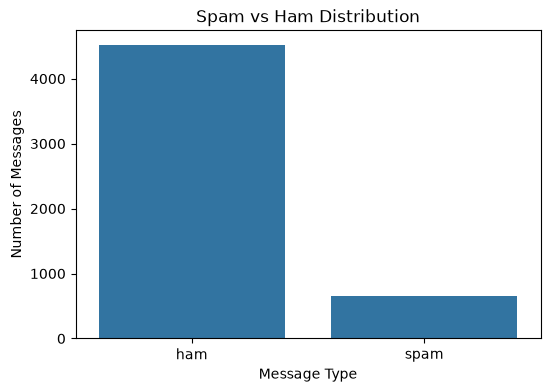

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [14]:
df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = " ".join(text.split())
    return text

In [16]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [17]:
for i in range(5):
    print("Original :", df["message"].iloc[i])
    print("Cleaned  :", df["clean_message"].iloc[i])
    print("-" * 80)

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
--------------------------------------------------------------------------------
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif u oni
--------------------------------------------------------------------------------
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs
--------------------------------------------------------------------------------
Original : U dun say so early hor... U c already then say...
Cleaned  : u dun say so early hor u c already then say
----------------------------

In [18]:
X = df["clean_message"]
y = df["label_num"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


In [19]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (5169, 5000)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4135
Testing samples: 1034


In [21]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

In [22]:
print("Multinomial Naive Bayes Results")

print("\nAccuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

print("\nClassification Report:")
print(classification_report(y_test, nb_predictions, target_names=["Ham", "Spam"]))

Multinomial Naive Bayes Results

Accuracy : 0.9690522243713733
Precision: 0.9900990099009901
Recall   : 0.7633587786259542
F1 Score : 0.8620689655172413

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       0.99      0.76      0.86       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



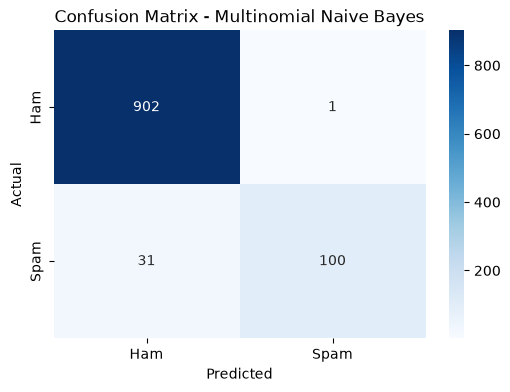

In [23]:
cm_nb = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [25]:
print("Logistic Regression Results")

print("\nAccuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, target_names=["Ham", "Spam"]))

Logistic Regression Results

Accuracy : 0.9429400386847195
Precision: 0.9864864864864865
Recall   : 0.5572519083969466
F1 Score : 0.7121951219512195

Classification Report:
              precision    recall  f1-score   support

         Ham       0.94      1.00      0.97       903
        Spam       0.99      0.56      0.71       131

    accuracy                           0.94      1034
   macro avg       0.96      0.78      0.84      1034
weighted avg       0.95      0.94      0.94      1034



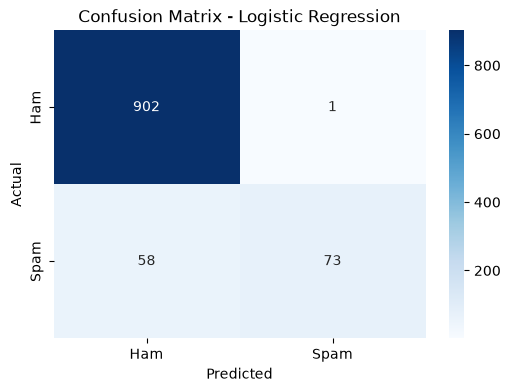

In [26]:
cm_lr = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, lr_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, lr_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, lr_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.969052,0.990099,0.763359,0.862069
1,Logistic Regression,0.942940,0.986486,0.557252,0.712195


In [28]:
best_model = results.loc[results["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Multinomial Naive Bayes
F1 Score: 0.8620689655172413


In [29]:
new_message = [
    "Congratulations! You have won a free prize. Click now to claim your reward!"
]

new_message_clean = [preprocess_text(message) for message in new_message]

new_message_tfidf = tfidf.transform(new_message_clean)

prediction = lr_model.predict(new_message_tfidf)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")

Prediction: Spam


In [30]:
new_message = [
    "Hey, are we meeting at college tomorrow?"
]

new_message_clean = [preprocess_text(message) for message in new_message]

new_message_tfidf = tfidf.transform(new_message_clean)

prediction = lr_model.predict(new_message_tfidf)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Ham")

Prediction: Ham


In [32]:
!pip install wordcloud


In [33]:
from wordcloud import WordCloud

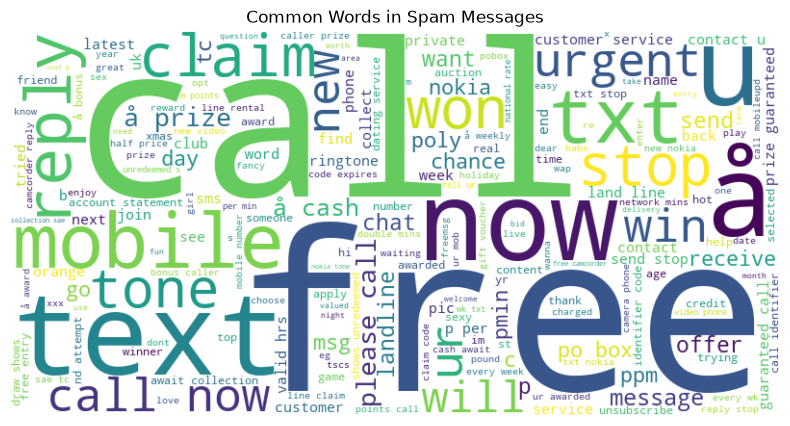

In [34]:
spam_text = " ".join(df[df["label"] == "spam"]["clean_message"])

wordcloud_spam = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

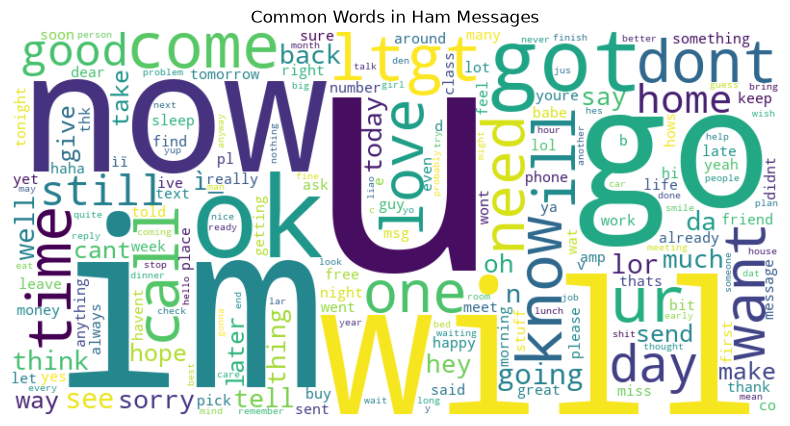

In [35]:
ham_text = " ".join(df[df["label"] == "ham"]["clean_message"])

wordcloud_ham = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_ham, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.show()

In [36]:
print("Final Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["label"].value_counts())

print("\nModel Comparison:")
display(results)

Final Dataset Shape: (5169, 4)

Class Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.969052,0.990099,0.763359,0.862069
1,Logistic Regression,0.942940,0.986486,0.557252,0.712195


## Conclusion

In this project, a Natural Language Processing (NLP) based machine learning system was developed to classify messages as Spam or Ham.

The text data was cleaned and preprocessed by converting messages to lowercase and removing punctuation and unnecessary characters. TF-IDF Vectorization was then used to convert the text into numerical features suitable for machine learning.

Two classification models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

The model comparison shows that both algorithms can effectively classify spam and legitimate messages. The model with the higher F1-score was considered the better-performing model for this dataset.

Recall is particularly important in spam detection because it measures how many actual spam messages are correctly identified. A low recall would mean that many spam messages are incorrectly classified as legitimate messages.

The WordCloud visualizations also helped identify frequently occurring words in spam and ham messages.

Overall, this project demonstrates how NLP, TF-IDF feature extraction, and machine learning classification algorithms can be combined to build an effective spam detection system.